# Model Update

## Install & Import Library

In [2]:
# Install Keras Tuner jika belum ada (wajib di Colab)
!pip install -q -U keras-tuner

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import os

2025-10-18 20:47:05.151169: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-18 20:47:05.918248: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-18 20:47:08.095440: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Blok ini meng-install dan meng-import seluruh library yang dibutuhkan termasuk keras-tuner.

## Muat & Pre-Processing CIFAR-10

In [3]:
# Cek & buat folder hasil
os.makedirs('result', exist_ok=True)
os.makedirs('metric', exist_ok=True)

# Muat dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalisasi nilai piksel ke [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encoding label
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Penjelasan:
Dataset di-load, dinormalisasi, dan label diubah ke one-hot vector.

## Data Augmentation

In [4]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)
datagen.fit(x_train)

Penjelasan:
Membuat variasi data gambar selama training untuk mencegah overfitting.

## Model CNN dengan Batch Normalization & Dropout

In [5]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/run/media/alannuarii/b25e065d-58a6-4c72-8784-0ed758d4cf00/home/alannuarii/Coding/Python/streamlit_cnn_cifar10/env/lib64/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-18 20:47:13.636764: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Penjelasan:
Model CNN dengan batch normalization & dropout agar lebih stabil dan anti-overfitting.

## Alternatif: Transfer Learning (MobileNetV2)

In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/tmp/ipykernel_130526/3963480209.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32,32,3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Penjelasan:
Jika ingin performa tinggi, gunakan MobileNetV2 sebagai feature extractor (ganti model dengan transfer_model di blok training).

## Hyperparameter Tuning dengan KerasTuner

In [7]:
def build_model(hp):
    model = models.Sequential()
    model.add(layers.Conv2D(
        filters=hp.Choice('conv_1_filter', [32, 64]),
        kernel_size=hp.Choice('conv_1_kernel', [3, 5]),
        padding='same',
        input_shape=(32, 32, 3)
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Conv2D(
        filters=hp.Choice('conv_2_filter', [64, 128]),
        kernel_size=hp.Choice('conv_2_kernel', [3, 5]),
        padding='same'
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(hp.Int('dense_units', 64, 256, step=32), activation='relu'))
    model.add(layers.Dropout(hp.Choice('dropout_rate', [0.3, 0.5])))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='kt_tuning',
    project_name='cifar10'
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

# Untuk tuning, jalankan blok ini (bisa lama)
# tuner.search(datagen.flow(x_train, y_train, batch_size=64), epochs=10, validation_data=(x_test, y_test), callbacks=callbacks)
# best_model = tuner.get_best_models(num_models=1)[0]

Penjelasan:
Blok ini untuk mencari kombinasi parameter terbaik. Jika ingin tuning, gunakan model best_model hasil tuning untuk training dan evaluasi.

## Kompilasi & Training Model

In [8]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50


/run/media/alannuarii/b25e065d-58a6-4c72-8784-0ed758d4cf00/home/alannuarii/Coding/Python/streamlit_cnn_cifar10/env/lib64/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2087 - loss: 2.1242

2025-10-18 20:48:05.088135: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 122880000 exceeds 10% of free system memory.


782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - accuracy: 0.2411 - loss: 1.9882 - val_accuracy: 0.3310 - val_loss: 1.7327 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.3045 - loss: 1.8095 - val_accuracy: 0.2479 - val_loss: 2.1558 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.3435 - loss: 1.7086 - val_accuracy: 0.4671 - val_loss: 1.4093 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 61ms/step - accuracy: 0.3657 - loss: 1.6571 - val_accuracy: 0.4485 - val_loss: 1.5422 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 61ms/step - accuracy: 0.3738 - loss: 1.6186 - val_accuracy: 0.4364 - val_loss: 1.5527 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.3847 - loss: 1.6020 - val_accuracy: 0.3813 - val_loss: 2.0248 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.4066 - loss: 1.5406

Penjelasan:
Training model utama (atau ganti model dengan transfer_model atau best_model jika mau).

## Visualisasi Hasil Training

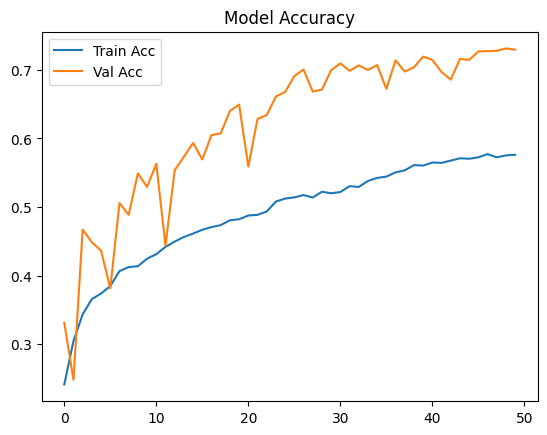

In [9]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()
plt.close()

Penjelasan:
Visualisasi performa model selama training.

## Simpan Model & Metrik

In [10]:
model.save('result/cifar10_cnn.keras')

training_metrics = {
    'accuracy': history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'],
    'loss': history.history['loss'],
    'val_loss': history.history['val_loss']
}
with open('metric/training_metrics.json', 'w') as f:
    json.dump(training_metrics, f)

df_history = pd.DataFrame(history.history)
df_history.to_csv('metric/training_history.csv', index=False)

Penjelasan:
Menyimpan model dan metrik training ke file untuk analisis atau deployment.

## Evaluasi Model (Akurasi Persentase)

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Akurasi pada data uji: {test_acc * 100:.2f}%")

 35/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7402 - loss: 0.7712

2025-10-18 21:25:52.893459: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 122880000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7313 - loss: 0.7881
Akurasi pada data uji: 73.13%


Penjelasan:
Mengevaluasi model pada data uji dan menampilkan akurasi.